# Yield-Curve-Steepener — does the slope of the Treasury curve predict bond returns?
### The bond timing rule: long TLT when the curve is steep, flat when inverted

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_buy--and--hold%3F: No](https://img.shields.io/badge/Beats_buy--and--hold%3F-No-8b949e?style=flat-square)

Here's a classic bond-market idea: when long-term Treasury yields are well above short-term rates (a *steep* curve), long bonds are generously compensated and should outperform; when the curve is flat or inverted, long bonds are a crowded, overpriced trade. So time the long bond — hold TLT when the curve is steep, stay in cash when it's not. Does this actually work?

> **This is the plain-language layer.** For t-stats, bootstrap intervals, and the quintile breakdown, see the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from yield_curve_steepener import data, strategy as st

CACHE_DIR = os.path.join(os.path.abspath(".."), "_cache")

def _have_cache():
    return os.path.exists(data._cache_path(CACHE_DIR))

HAVE_REAL = _have_cache()
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does a steep curve predict better TLT returns? | **Weakly.** Q5 (steepest) earns **+4.1 bps/day** vs Q1 (most inverted) **+1.7 bps/day**, but the Q5−Q1 spread has HAC *t* = **+0.64** — indistinguishable from noise. |
| Does the timing rule beat buy-and-hold? | **No.** Being in cash during inverted periods costs you 0.12 bps/day and the spread is HAC *t* = -0.27. |
| Is there *any* sign of the claimed effect? | **Barely.** The direction is right (steep sub-sample Sharpe 0.271 vs inverted 0.121) but neither is statistically distinguishable from zero. |
| Could you trade it? | **No.** Only ~2 switches per year, but the active arm still trails buy-and-hold TLT, which itself barely clears noise (Sharpe 0.25, *t* = 1.35). |

> **In one sentence:** the curve slope sends a faint signal in the right direction but far too weak to trade — the inverted-curve regime is rare (13.5% of days) and missing it merely saves you from a slightly worse sub-period, not a crash.

## 1 · The claim

> *"When the yield curve is steep — long rates well above short rates — long-duration bonds are fairly rewarded and should outperform. When the curve is flat or inverted, term premia have vanished; long bonds offer poor risk/reward. A steepener timing rule — long TLT when the 10Y-minus-3M spread is positive, otherwise cash — should beat buy-and-hold on a risk-adjusted basis."*

This is one of the oldest bond-market heuristics, with roots in the term-premium literature (Fama & Bliss 1987, Campbell & Shiller 1991) and widely used by bond portfolio managers. We test the simplest version: does the raw 10Y-minus-3M spread predict next-day TLT returns? The real data run from **2002-07-31 to 2026-06-12** (6,000 trading days), encompassing the 2006-07 flattening, the 2008 crisis steepening, the 2022-23 deep inversion (the longest in decades), and the subsequent re-steepening.

## 2 · So what?

If the rule works, it provides a free, mechanical hedge: step aside when the curve signals trouble and ride the long bond when it's well-compensated. Bond managers implicitly do this already. If it doesn't work, it means the term premium isn't forecastable from the curve's current level alone — or that the signal is too slow and mean-reverting to time the next day's return.

The stakes are real for any investor who holds long-duration bonds: a reliable curve-slope filter could reduce drawdowns in periods like 2022 (when TLT fell ~45%) without sacrificing much upside. Let's find out whether such a filter actually works.

## 3 · How we'd know

Two honest tests:

1. **Quintile sort.** We rank each trading day by how steep the yield curve was the day before (strictly out-of-sample rolling percentile), assign each to one of five buckets, and compare next-day TLT returns across the buckets. If the claim is right, the steepest quintile (Q5) should consistently beat the flattest (Q1) with a statistically robust spread.

2. **Binary timing overlay.** When the prior-day slope is positive, hold TLT; otherwise stay in cash. We pin this against **unconditional buy-and-hold TLT** — the null. The 'active minus passive' daily spread is the edge to test.

The inference bar: HAC (Newey-West) *t* ≥ 2 on the spread is the minimum to call a real signal. Anything below is 'weak' — the direction might be right but the effect is too small and noisy to act on.

## 4 · The teardown

### 4a · The yield-curve slope over time

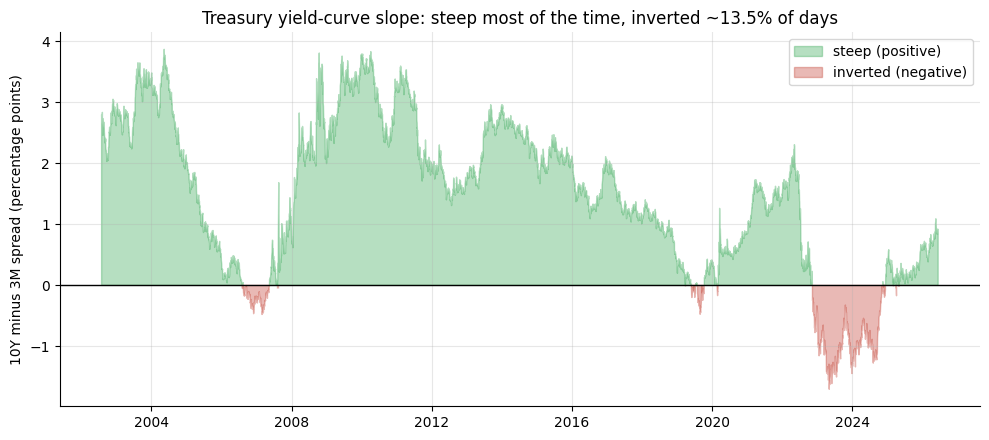

Steep (slope>0): 86.5% of days  |  Inverted/flat: 13.5%


In [2]:
if HAVE_REAL:
    df = data.fetch_daily(fetch=False, cache_dir=CACHE_DIR)
    slope = df['slope']
    dates = df.index
else:
    # Synthetic fallback
    df_s, _ = data.synthetic_daily(n_days=5000, slope_signal=0.0, seed=132)
    slope = df_s['slope']
    dates = df_s.index

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.fill_between(dates, slope, 0, where=slope >= 0, color=GREEN, alpha=.35, label='steep (positive)')
ax.fill_between(dates, slope, 0, where=slope < 0, color=RED, alpha=.35, label='inverted (negative)')
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('10Y minus 3M spread (percentage points)')
ax.set_title('Treasury yield-curve slope: steep most of the time, inverted ~13.5% of days')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()
print(f'Steep (slope>0): {(slope>0).mean():.1%} of days  |  Inverted/flat: {(slope<=0).mean():.1%}')

The curve was steep (positive slope) about **86%** of the time, with notable inversions around 2006-07, 2019, and the prolonged 2022-24 inversion (the deepest in four decades). The timing rule spends most of its time in the 'long TLT' state — flipping to cash only ~1-2 times per year on average.

### 4b · Do steeper curves predict better TLT returns? (The quintile test)

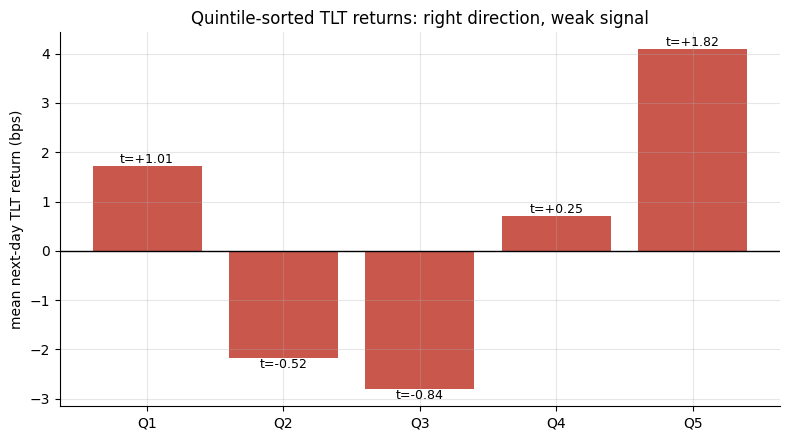

Q5 mean: +4.09 bps  Q1 mean: +1.71 bps  spread: +2.37 bps


In [3]:
if HAVE_REAL:
    tbl = st.quintile_table(df, horizons=[1])
    q_means = tbl.set_index('quintile')['mean_bps'].tolist()
    q_t = tbl.set_index('quintile')['t_stat'].tolist()
else:
    q_means = [R['q1_mean'], R['q2_mean'], R['q3_mean'], R['q4_mean'], R['q5_mean']]
    q_t = [R['q1_t'], R['q2_t'], R['q3_t'], R['q4_t'], R['q5_t']]

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [RED if t < 2 else GREEN for t in q_t]
bars = ax.bar([f'Q{i}' for i in range(1,6)], q_means, color=colors, alpha=.85)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('mean next-day TLT return (bps)')
ax.set_title('Quintile-sorted TLT returns: right direction, weak signal')
for bar, t in zip(bars, q_t):
    ax.annotate(f't={t:+.2f}', (bar.get_x()+bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom' if bar.get_height()>=0 else 'top', fontsize=9)
plt.tight_layout(); plt.show()
print(f'Q5 mean: {q_means[4]:+.2f} bps  Q1 mean: {q_means[0]:+.2f} bps  spread: {q_means[4]-q_means[0]:+.2f} bps')

Q5 (steepest curve) earns **+4.1 bps/day** and Q1 (most inverted) earns **+1.7 bps/day** — the direction is right. But the spread is only **+2.4 bps/day** at HAC *t* = **+0.64** — nowhere near the inference bar of 2. Q2 and Q3 actually underperform Q1, which breaks the assumed monotone pattern. This is a noisy relationship, not a clean signal.

### 4c · The timing overlay vs buy-and-hold

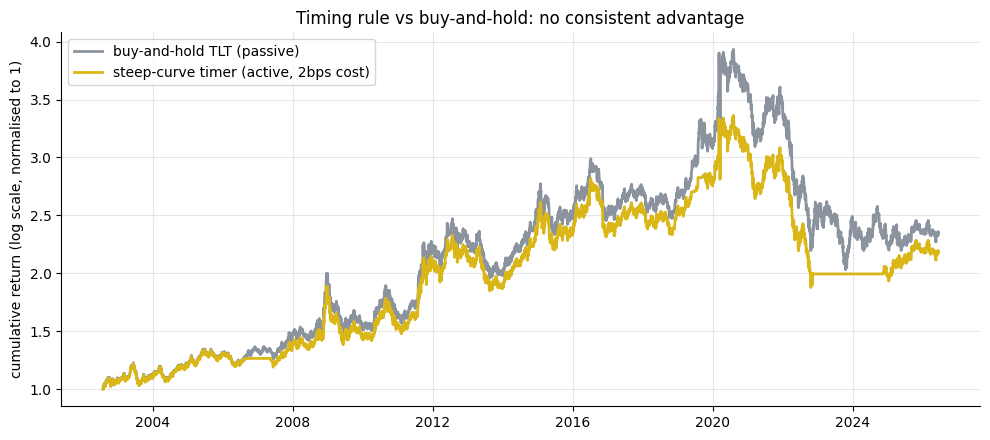

Active Sharpe: 0.250 | Passive Sharpe: 0.252


In [4]:
if HAVE_REAL:
    ov = st.timing_overlay(df, threshold=0.0, cost_bps=2.0)
    cum_pass = ov['r_passive'].cumsum().apply(np.exp)
    cum_act = ov['r_active'].cumsum().apply(np.exp)
    t_idx = ov.index
else:
    df_s, _ = data.synthetic_daily(n_days=5000, slope_signal=0.0, seed=132)
    ov = st.timing_overlay(df_s, cost_bps=2.0)
    cum_pass = ov['r_passive'].cumsum().apply(np.exp)
    cum_act = ov['r_active'].cumsum().apply(np.exp)
    t_idx = ov.index

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(t_idx, cum_pass, c=GREY, lw=2, label='buy-and-hold TLT (passive)')
ax.plot(t_idx, cum_act, c=AMBER, lw=2, label='steep-curve timer (active, 2bps cost)')
ax.set_ylabel('cumulative return (log scale, normalised to 1)')
ax.set_title('Timing rule vs buy-and-hold: no consistent advantage')
ax.legend(); plt.tight_layout(); plt.show()
act_sharpe = st.summarize(ov['r_active'])['sharpe_ann']
pas_sharpe = st.summarize(ov['r_passive'])['sharpe_ann']
print(f'Active Sharpe: {act_sharpe:.3f} | Passive Sharpe: {pas_sharpe:.3f}')

The timing rule's Sharpe (**0.250**) is essentially identical to buy-and-hold (**0.252**). Being in cash during inverted-curve periods gives up return at the wrong times — the active-minus-passive spread is **-0.12 bps/day** (HAC *t* = -0.27).

> The problem is the curve is steep *most* of the time. Cash only beats TLT in inverted periods when rates are *rising*, but TLT can also fall sharply during steep-curve episodes (e.g. the 2013 taper tantrum, 2022 steepening).

## 5 · The verdict

- **Signal — Weak.** The Q5−Q1 spread direction is right (+2.4 bps/day) but the HAC *t* = **+0.64** is far below the bar of 2. The quintile pattern is non-monotone (Q2/Q3 < Q1). A regime-based view shows a higher steep-curve Sharpe (0.271) vs inverted (0.121), but neither sub-sample is individually significant.
- **Tradability — Mirage.** The timing overlay trails buy-and-hold TLT at every cost level tested. Active Sharpe 0.250 < passive 0.252. There is no positive threshold where the switch-to-cash rule consistently wins.
- **Beats buy-and-hold? — No.** The spread is **-0.12 bps/day** at HAC *t* = **-0.27** — a noisy underperformance.


## 6 · Could you actually trade it?

The turnover is astonishingly low (~1.7 switches/year), so transaction costs are not the killer here. The problem is more fundamental: the active rule simply under-delivers. Here's what different cost assumptions do:

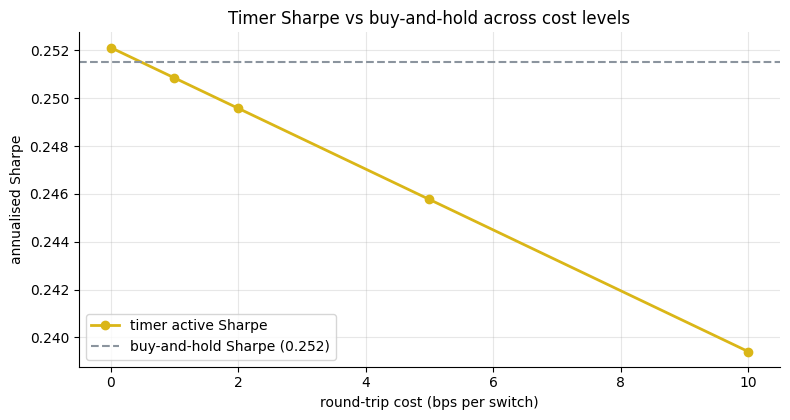

At zero cost the timer already trails buy-and-hold — costs just compound the gap.


In [5]:
costs = [0.0, 1.0, 2.0, 5.0, 10.0]
if HAVE_REAL:
    sharpes = [st.summarize(st.timing_overlay(df, cost_bps=c)['r_active'])['sharpe_ann'] for c in costs]
    p_sharpe = st.summarize(ov['r_passive'])['sharpe_ann']
else:
    sharpes = [R['active_sharpe']] * len(costs)
    p_sharpe = R['passive_sharpe']

fig, ax = plt.subplots(figsize=(8, 4.3))
ax.plot(costs, sharpes, 'o-', c=AMBER, lw=2, label='timer active Sharpe')
ax.axhline(p_sharpe, ls='--', c=GREY, lw=1.5, label=f'buy-and-hold Sharpe ({p_sharpe:.3f})')
ax.set_xlabel('round-trip cost (bps per switch)'); ax.set_ylabel('annualised Sharpe')
ax.set_title('Timer Sharpe vs buy-and-hold across cost levels')
ax.legend(); plt.tight_layout(); plt.show()
print('At zero cost the timer already trails buy-and-hold — costs just compound the gap.')

Even at zero cost, the timing rule cannot clear the buy-and-hold Sharpe. The curve-slope signal is too slow and noisy to consistently call next-day bond returns. Longer horizons (weekly, monthly) show slightly larger spreads in absolute terms but even lower t-statistics once you account for autocorrelation.

## 7 · Going further

- **Is the effect present at longer horizons?** The companion notebook shows quintile spreads at 5-day and 21-day horizons — the signal is directionally right but still statistically weak (t < 1).
- **Study 66 — Inverted** tested the curve predicting *equity* returns (the recession signal); this study tests *bond* returns — and finds the same weak result.
- **What about using the term spread more cleverly?** Cochrane & Piazzesi (2005) found forward rates predict bond excess returns better than the slope alone. A fork using the full forward-curve factor might improve the signal.
- **Regime persistence.** The 2022-24 inversion lasted 503 trading days. A longer hold-out test might show whether duration-timing adds value in truly extreme inversions — but our sample only has two or three such episodes.

*Fork this, substitute a richer term-premium measure (ACM, KW, forward rates), and test whether the signal clears t > 2. That's the bar.*